## Convocatoria 1 - Proyecto 1

#### 0) Cargar una de las imágenes histológicas

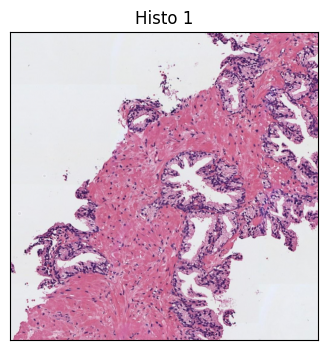

In [1]:
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
import cv2

def get_imagen_original_normalizada(ruta_imagen):
    # Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
    img = io.imread(ruta_imagen)
    
    # Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
    rgb = img.copy()
    rgb_normalizada = rgb.astype('uint8')/255

    return rgb, rgb_normalizada

def visualizar_imagen(imagen, titulo):
    fig, axes = plt.subplots(1, 1, figsize=(10, 4))
    axes.imshow(imagen, cmap='gray');   
    axes.set_title(titulo);        
    axes.set_xticks([]); 
    axes.set_yticks([])
    axes.set_visible(True)
    plt.show()

histo_1, histo_1_normalizada = get_imagen_original_normalizada('./histo_1.jpg')
visualizar_imagen(histo_1_normalizada, "Histo 1")

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

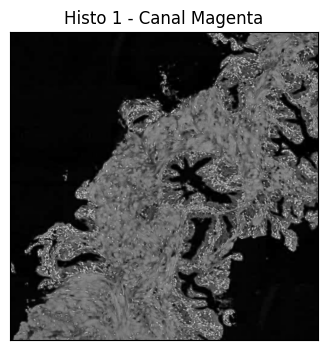

In [2]:
def obtener_CMYK(imagen_normalizada):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(imagen_normalizada, axis=2)
        C = (1-imagen_normalizada[:,:,0]-K)/(1-K)
        M = (1-imagen_normalizada[:,:,1]-K)/(1-K)
        Y = (1-imagen_normalizada[:,:,2]-K)/(1-K)
    
    CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
    C,M,Y,K = cv2.split(CMYK)
    return C,M,Y,K
    
    
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta
histo_1_C, histo_1_M, histo_1_Y, histo_1_K = obtener_CMYK(histo_1_normalizada)

visualizar_imagen(histo_1_M.astype('uint8'), 'Histo 1 - Canal Magenta')

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

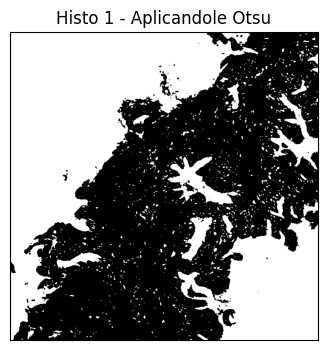

In [73]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

def transformar_imagen_a_float32(imagen):
  imagen_float_32 = imagen.astype(np.float32)
  return imagen_float_32


def aplicar_filtro_gauss_outsu_y_visualizar(imagen):
    imagen_32 = transformar_imagen_a_float32(imagen) # Se transforma a 32 float para poder escalar a grices con cv2.cvtColor
    imagen_32_gray = cv2.cvtColor(imagen_32, cv2.COLOR_BGR2GRAY)
    imagen_gray_u8 = (imagen_32_gray.astype(np.float32) * 255).clip(0, 255).astype(np.uint8) # Se pasa a u8 la escala de grises para poder graficar

    gaussian_blur = cv2.GaussianBlur(imagen_gray_u8, (5, 5), 0)
    _, gaussian_blur_mask = cv2.threshold(gaussian_blur, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_mask = cv2.threshold(gaussian_blur_mask, 0, 1, cv2.THRESH_OTSU)

    visualizar_imagen(otsu_mask, "Histo 1 - Aplicandole Otsu")

    return otsu_mask

histo_1_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_1_normalizada)

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

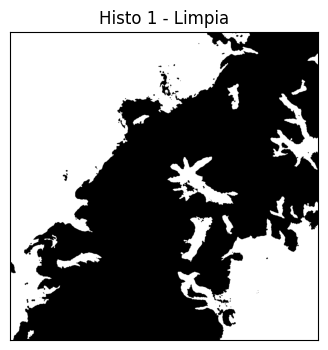

In [4]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante
from skimage.morphology import remove_small_objects

histo_1_bool = histo_1_otsu_mask.astype(bool)
histo_1_limpia = remove_small_objects(histo_1_bool, min_size=301).astype(np.uint8)
visualizar_imagen(histo_1_limpia, "Histo 1 - Limpia")

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

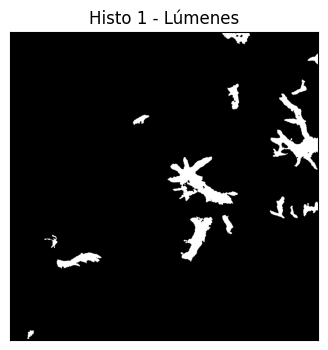

In [5]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

def rellenar_fondo(imagen):
    # Crear una copia de la imagen
    imagen_copia = imagen.copy()
    
    # Definir una imagen negra de referencia
    h, w = imagen.shape
    ref = np.zeros((h+2, w+2), np.uint8)
    
    # Fijar la semilla. En este caso en la esquina superior izquierda (posición 0,0) para rellenar a partir de ahí
    cv2.floodFill(imagen_copia, ref, (0, 0), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

    # Fijar la semilla. En este caso en la esquina inferior derecha (posición 0,0) para rellenar a partir de ahí
    cv2.floodFill(imagen_copia, ref, (h - 1, w - 1), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

    return imagen_copia

histo_1_lumenes = rellenar_fondo(histo_1_limpia)
visualizar_imagen(histo_1_lumenes, "Histo 1 - Lúmenes")

#### 5) Rellenar los objetos de los lúmenes

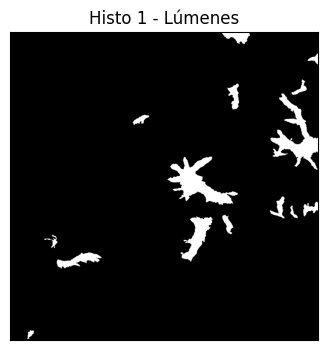

In [6]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante
from  scipy.ndimage import binary_fill_holes

histo_1_lumenes_fill = binary_fill_holes(histo_1_lumenes.copy())
visualizar_imagen(histo_1_lumenes_fill, "Histo 1 - Lúmenes")

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

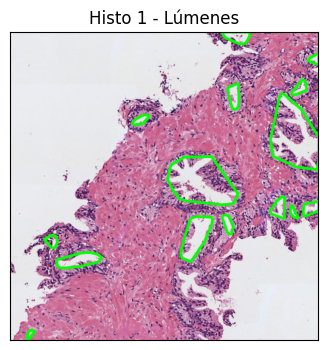

In [8]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta
from skimage.measure import regionprops
from skimage.measure import label
from skimage.morphology import convex_hull_image

def contornear_lumenes(imagen_original, etiquetas, num_etiquetas):
    imagen = imagen_original.copy()
    
    for i in range(1, num_etiquetas + 1):
        lumen = etiquetas == i
        lumen = lumen.astype('uint8')
        
        convex_image = convex_hull_image(lumen)
        convex_image = convex_image.astype('uint8')
    
        contours,_ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Encontramos los contornos en una máscara
        imagen = cv2.drawContours(imagen, contours, -1, (0,255,0), 7) # Dibujamos los contornos

    return imagen

histo_1_etiquetas, histo_1_num_etiquetas = label(histo_1_lumenes_fill, return_num=True)
histo_1_con_contorno = contornear_lumenes(histo_1, histo_1_etiquetas, histo_1_num_etiquetas)
visualizar_imagen(histo_1_con_contorno, "Histo 1 - Lúmenes")

#### 7) Identificar y cropear el lumen más grande

El lumen 7 tiene el mayor área: 13367.0


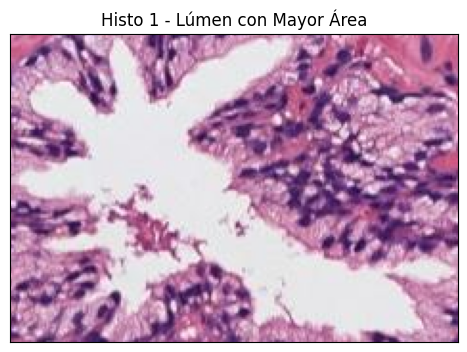

In [70]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

def obtener_propiedades_lumenes(etiquetas, num_etiquetas):
    A,BB,CA,E,ED,EX, DF, MA,MiA,OR,P,S,CO = ['Área'], ['Área de la bounding box'], ['Área convexa'],  \
    ['Exentricidad'], ['Diámetro equivalente'], ['Extensión'], ['Diámetro Feret'],  \
    ['Longitud del eje mayor'], ['Longitud del eje menor'], ['Orientación'], ['Perímetro'], \
    ['Solidez'], ['Compacidad']
    
    for i in range(1, num_etiquetas + 1):
        lumen = etiquetas == i
        lumen = lumen.astype('uint8')
    
        prop = regionprops(lumen.astype(np.uint8))

        A.append(np.round(prop[0].area, 4))
        BB.append(np.round(prop[0].bbox_area, 4))
        CA.append(np.round(prop[0].convex_area, 4))
        E.append(np.round(prop[0].eccentricity, 4))
        ED.append(np.round(prop[0].equivalent_diameter, 4))
        EX.append(np.round(prop[0].extent, 4))
        DF.append(np.round(prop[0].feret_diameter_max, 4))
        MA.append(np.round(prop[0].major_axis_length, 4))
        MiA.append(np.round(prop[0].minor_axis_length, 4))
        OR.append(np.round(prop[0].orientation, 4))
        P.append(np.round(prop[0].perimeter, 4))
        S.append(np.round(prop[0].solidity, 4))
        CO.append(np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4))

    propiedades = [tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX), tuple(DF), \
          tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO)]

    return propiedades

def crop_lumen_con_mayor_area(imagen, etiquetas, propiedades):
    areas = np.array(propiedades[0][1:])
    posicion = areas.argmax() + 1
    print(f"El lumen {posicion} tiene el mayor área: {areas.max()}")

    lumen = etiquetas == posicion
    lumen = lumen.astype('uint8')
    prop = regionprops(lumen.astype(np.uint8))
    minr, minc, maxr, maxc = prop[0].bbox
    return imagen[minr:maxr, minc:maxc]
    
histo_1_propiedades = obtener_propiedades_lumenes(histo_1_etiquetas, histo_1_num_etiquetas)
histo_1_crop = crop_lumen_con_mayor_area(histo_1, histo_1_etiquetas, histo_1_propiedades)
visualizar_imagen(histo_1_crop, "Histo 1 - Lúmen con Mayor Área")


#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [50]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

from tabulate import tabulate
import math

def tabular_informacion(propiedades):
    num = len(propiedades[0]) - 1
    headers = [f"Lume {num}" for num in range(1, num + 1)]
    print(tabulate(propiedades, headers=headers))

tabular_informacion(histo_1_propiedades)

                            Lume 1     Lume 2     Lume 3     Lume 4      Lume 5     Lume 6      Lume 7     Lume 8     Lume 9    Lume 10    Lume 11     Lume 12    Lume 13    Lume 14    Lume 15
-----------------------  ---------  ---------  ---------  ---------  ----------  ---------  ----------  ---------  ---------  ---------  ---------  ----------  ---------  ---------  ---------
Área                     2288        647        820       1821       12595        836       13367       1377       1249        378       1085        6327        481       3499        347
Área de la bounding box  3800       1406       2550       3230       40894       1870       37674       3577       2548       1050       2368       16006       1892       7897        660
Área convexa             2709        851       1373       2465       27955       1059       27468       2339       1892        570       1436        9540       1226       5250        435
Exentricidad                0.9207     0.6399     0.898

## Se Repite el Proceso con la Segunda Imagen

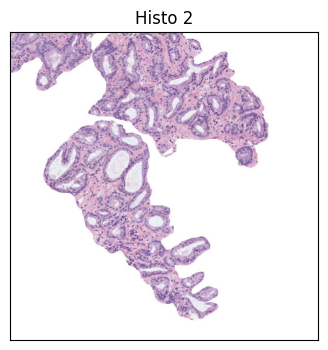

In [71]:
histo_2, histo_2_normalizada = get_imagen_original_normalizada('./histo_2.jpg')
visualizar_imagen(histo_2_normalizada, "Histo 2")

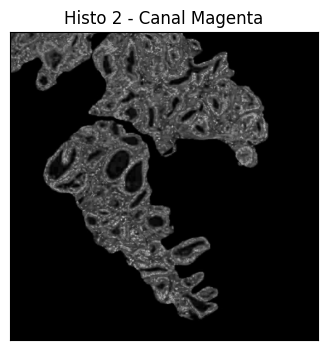

In [72]:
histo_2_C, histo_2_M, histo_2_Y, histo_2_K = obtener_CMYK(histo_2_normalizada)
visualizar_imagen(histo_2_M.astype('uint8'), 'Histo 2 - Canal Magenta')

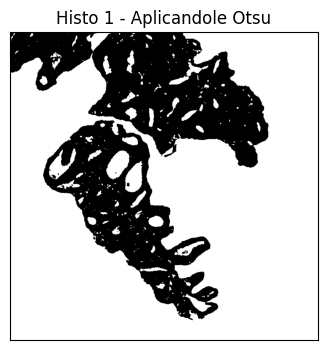

In [75]:
histo_2_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_2_normalizada)

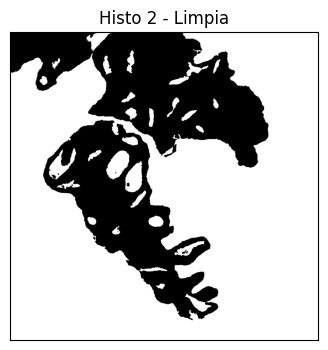

In [76]:
histo_2_bool = histo_2_otsu_mask.astype(bool)
histo_2_limpia = remove_small_objects(histo_2_bool, min_size=301).astype(np.uint8)
visualizar_imagen(histo_2_limpia, "Histo 2 - Limpia")

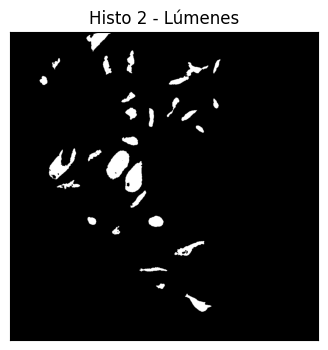

In [77]:
histo_2_lumenes = rellenar_fondo(histo_2_limpia)
visualizar_imagen(histo_2_lumenes, "Histo 2 - Lúmenes")

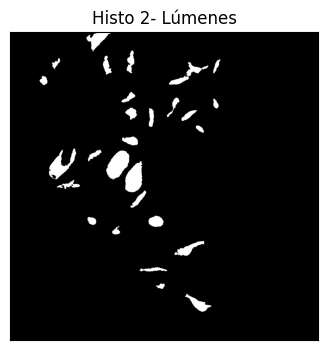

In [78]:
histo_2_lumenes_fill = binary_fill_holes(histo_2_lumenes.copy())
visualizar_imagen(histo_2_lumenes_fill, "Histo 2- Lúmenes")

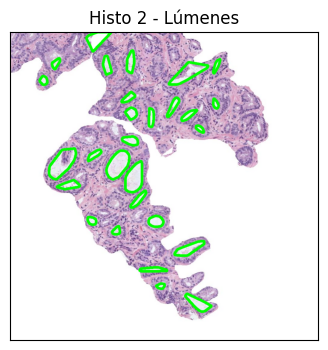

In [79]:
histo_2_etiquetas, histo_2_num_etiquetas = label(histo_2_lumenes_fill, return_num=True)
histo_2_con_contorno = contornear_lumenes(histo_2, histo_2_etiquetas, histo_2_num_etiquetas)
visualizar_imagen(histo_2_con_contorno, "Histo 2 - Lúmenes")

El lumen 18 tiene el mayor área: 4683.0


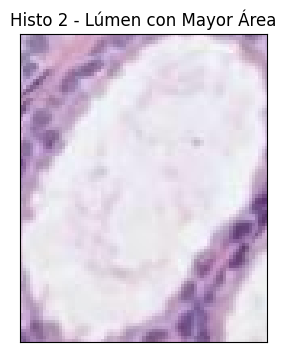

In [80]:
histo_2_propiedades = obtener_propiedades_lumenes(histo_2_etiquetas, histo_2_num_etiquetas)
histo_2_crop = crop_lumen_con_mayor_area(histo_2, histo_2_etiquetas, histo_2_propiedades)
visualizar_imagen(histo_2_crop, "Histo 2 - Lúmen con Mayor Área")

In [81]:
tabular_informacion(histo_2_propiedades)

                            Lume 1     Lume 2     Lume 3    Lume 4     Lume 5     Lume 6    Lume 7     Lume 8     Lume 9    Lume 10    Lume 11    Lume 12    Lume 13    Lume 14    Lume 15    Lume 16    Lume 17    Lume 18    Lume 19    Lume 20    Lume 21    Lume 22    Lume 23    Lume 24    Lume 25    Lume 26    Lume 27    Lume 28
-----------------------  ---------  ---------  ---------  --------  ---------  ---------  --------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------  ---------
Área                     2306       1064        958       413        444       2137       527        656        665        380        927        805        744        365       1076       3535        659       4683       4200        819        910       1405        568        413       1799        746        319       1756
Área de la boun